<a href="https://colab.research.google.com/github/raynarah/meu-site/blob/main/dados_conexao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Componentes de validação e otimização
from sklearn.model_selection import train_test_split, GridSearchCV

# Modelos candidatos solicitados
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize, LabelEncoder

# 1. CARREGAMENTO E PREPARAÇÃO DOS DADOS
df = pd.read_csv('/dados_conexao - dados_sinal.csv')

coluna_alvo = 'CS'
y = df[coluna_alvo]
X = df.drop(columns=[coluna_alvo])

# O XGBoost exige que as classes alvo sejam numéricas ordenadas (0, 1, 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes_originais = list(le.classes_)  # Guarda a ordem ('Bom', 'Médio', 'Ruim')

In [15]:
# 2. ENGENHARIA DE FEATURES (Pré-processamento)
if 'HD' in X.columns:
    X['HD'] = pd.to_datetime(X['HD'])
    X['Hora_do_dia'] = X['HD'].dt.hour
    X = X.drop(columns=['HD'])

colunas_categoricas = ['LC', 'TR', 'OP', 'BA', 'NC', 'CS']
colunas_presentes = [col for col in colunas_categoricas if col in X.columns]
X = pd.get_dummies(X, columns=colunas_presentes, drop_first=True)

# 3. PROTOCOLO EXPERIMENTAL (Divisão dos Dados)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

In [17]:
# 4. AVALIAÇÃO EXPERIMENTAL: HIPERPARÂMETROS (RF)

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

rf_base = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=3,
    scoring='roc_auc_ovr_weighted',
    n_jobs=-1
)
grid_search_rf.fit(X_train, y_train)
rf_otimizado = grid_search_rf.best_estimator_

# Definindo o dicionário com o novo conjunto representativo
modelos_finais = {
    "Árvore de Decisão (Padrão)": DecisionTreeClassifier(random_state=42),
    "Random Forest (OTIMIZADO)": rf_otimizado,
    "XGBoost (Boosting)": XGBClassifier(random_state=42, eval_metric='mlogloss')
}

# Preparação para métricas visuais
resultados_auc = {}
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = len(classes_originais)

------------------------------------------------------------
Processando avaliações para: Árvore de Decisão (Padrão)


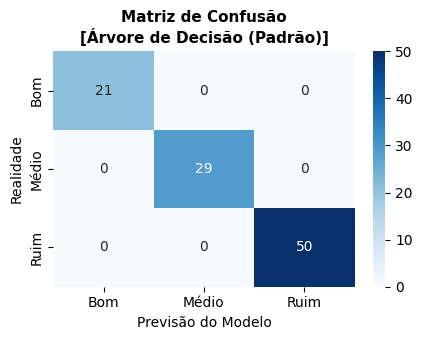

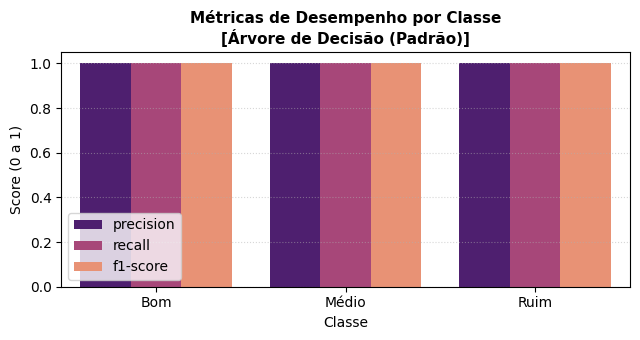

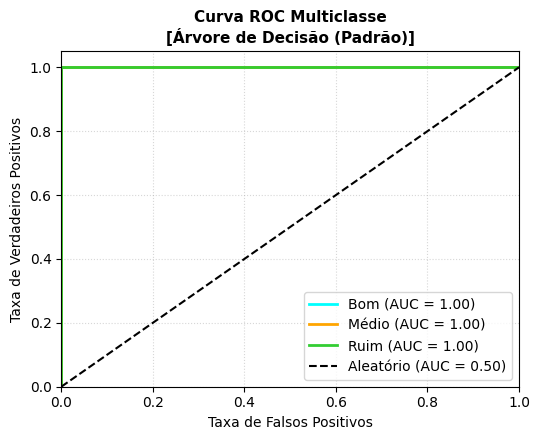

------------------------------------------------------------
Processando avaliações para: Random Forest (OTIMIZADO)


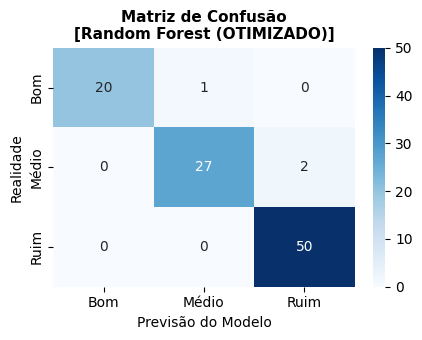

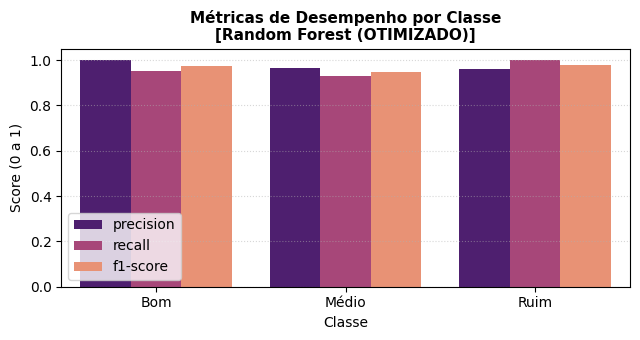

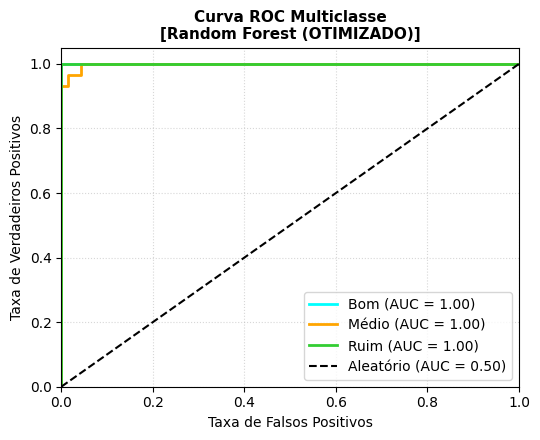

------------------------------------------------------------
Processando avaliações para: XGBoost (Boosting)


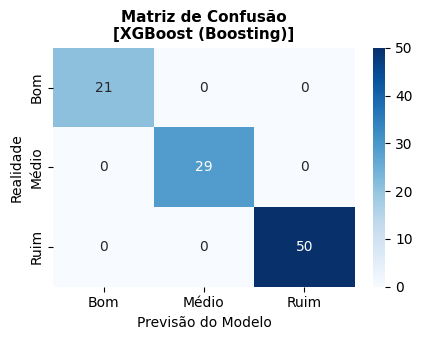

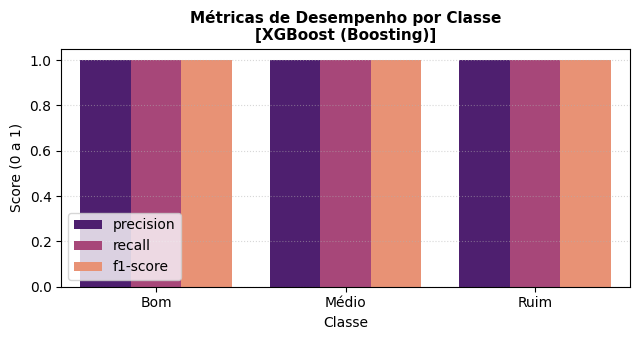

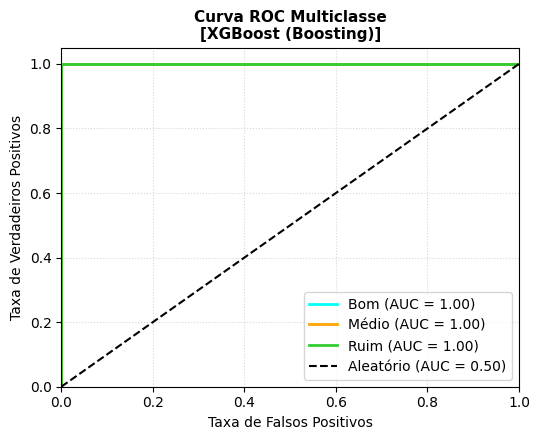

In [18]:
# 5. EXECUÇÃO, MATRIZES E RELATÓRIOS EM GRÁFICOS

for nome, modelo in modelos_finais.items():
    print("-" * 60)
    print(f"Processando avaliações para: {nome}")

    # Treino e Predições
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)

    # Cálculo do AUC-ROC global do modelo
    auc_macro = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    resultados_auc[nome] = auc_macro

    # Extração das métricas textuais do relatório para convertê-las em DataFrame
    report_dict = classification_report(y_test, y_pred, target_names=classes_originais, output_dict=True)
    df_metrics = pd.DataFrame(report_dict).iloc[:-1, :n_classes].T.reset_index().rename(columns={'index': 'Classe'})

    # --- VISUALIZAÇÃO 1: Matriz de Confusão ---
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4.5, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes_originais, yticklabels=classes_originais)
    plt.title(f'Matriz de Confusão\n[{nome}]', fontsize=11, weight='bold')
    plt.ylabel('Realidade')
    plt.xlabel('Previsão do Modelo')
    plt.tight_layout()
    plt.show()

    # --- VISUALIZAÇÃO 2: Gráfico do Relatório de Classificação (Substitui texto) ---
    df_melted = pd.melt(df_metrics, id_vars='Classe', var_name='Métrica', value_name='Score')
    plt.figure(figsize=(6.5, 3.5))
    sns.barplot(x='Classe', y='Score', hue='Métrica', data=df_melted, palette='magma')
    plt.title(f'Métricas de Desempenho por Classe\n[{nome}]', fontsize=11, weight='bold')
    plt.ylim(0, 1.05)
    plt.ylabel('Score (0 a 1)')
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.legend(loc='lower left')
    plt.tight_layout()
    plt.show()

    # --- VISUALIZAÇÃO 3: Gráfico da Curva ROC Individual ---
    plt.figure(figsize=(5.5, 4.5))
    colors = ['cyan', 'orange', 'limegreen']
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{classes_originais[i]} (AUC = {auc(fpr, tpr):.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aleatório (AUC = 0.50)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos')
    plt.ylabel('Taxa de Verdadeiros Positivos')
    plt.title(f'Curva ROC Multiclasse\n[{nome}]', fontsize=11, weight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

------------------------------------------------------------
📊 GERANDO COMPARATIVO FINAL DE DESEMPENHO...


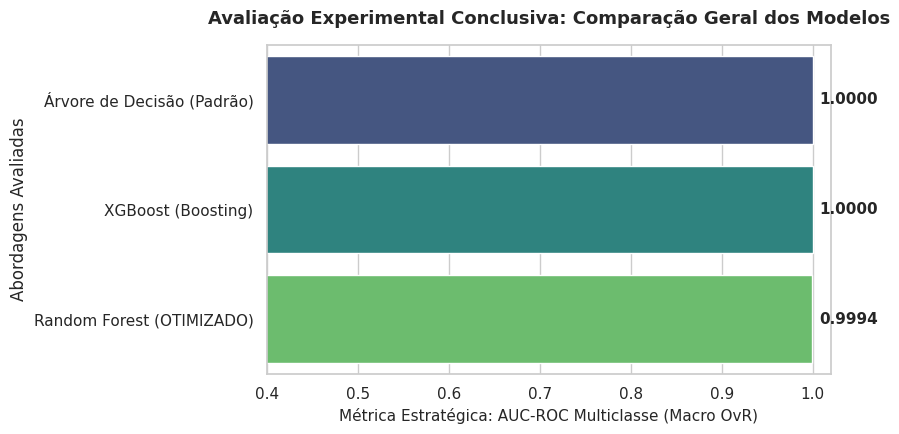

In [19]:
# 6. GRÁFICO COMPARATIVO FINAL (MÉTRICA GLOBAL)
print("-" * 60)
print("📊 GERANDO COMPARATIVO FINAL DE DESEMPENHO...")

df_resultados = pd.DataFrame(list(resultados_auc.items()), columns=['Modelo', 'AUC-ROC']).sort_values(by='AUC-ROC', ascending=False)

plt.figure(figsize=(9, 4.5))
sns.set_theme(style="whitegrid")
grafico = sns.barplot(x='AUC-ROC', y='Modelo', data=df_resultados, palette='viridis', hue='Modelo', legend=False)

for container in grafico.containers:
    grafico.bar_label(container, fmt='%.4f', padding=5, fontsize=11, weight='bold')

plt.title('Avaliação Experimental Conclusiva: Comparação Geral dos Modelos', fontsize=13, weight='bold', pad=15)
plt.xlabel('Métrica Estratégica: AUC-ROC Multiclasse (Macro OvR)', fontsize=11)
plt.ylabel('Abordagens Avaliadas')
plt.xlim(0.4, 1.02)
plt.tight_layout()
plt.show()